In [29]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam, Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

import time
import os
from sklearn.utils.class_weight import compute_class_weight

from featureimportance import compute_feature_importance_from_AW,plot_top_genes_from_AW,plot_all_genes_from_AW


# Define defaults
toggle = os.environ.get("toggle", "small")  # Default to "small"
SVI_z_n_steps = int(os.environ.get("SVI_z_n_steps", 3000))  # Default to 3000
SVI_PPCA_n_steps = int(os.environ.get("SVI_PPCA_n_steps", 3000))  # Default to 3000


In [30]:
def load_small_data():
    pyro.set_rng_seed(42)

    # Load small dataset
    test_data_path = "small_test_data.csv"
    test_label_path = "small_test_labels.csv"
    test_data = pd.read_csv(test_data_path).values.astype(np.float32)
    test_label = pd.read_csv(test_label_path).values.flatten()

    val_data_path = "small_val_data.csv"
    val_label_path = "small_val_labels.csv"
    val_data = pd.read_csv(val_data_path).values.astype(np.float32)
    val_label = pd.read_csv(val_label_path).values.flatten()

    genes_path = "gene_label.csv"
    gene_names = pd.read_csv(genes_path, header=None).values[:400,0]
    gene_type = pd.read_csv(genes_path, header=None).values[:400,1]

    return test_data, test_label, val_data, val_label, gene_names, gene_type



def load_large_data():
    pyro.set_rng_seed(42)
    torch.set_num_threads(8)

    # File paths
    train_path = "/work3/s214806/working_chunk_train.csv"
    val_path = "/work3/s214806/working_chunk_val.csv"
    test_path = "/work3/s214806/working_chunk_test.csv"

    LABEL_MAPPING = {'AML': 0, 'ALL': 1, 'Normal': 2}



    # Load and preprocess data
    def load_and_preprocess(path):
        df = pd.read_csv(path, index_col=0, low_memory=False).T
        print(f"Gene expression data BEFORE removing non-numeric columns: {df.shape[1]}")

        labels = df['Cancer'].map(LABEL_MAPPING).dropna()

        gene_expressions = df.drop(['Cancer', 'Preservation Method', 'Tissue Type', 'Tumor Descriptor', 'Specimen Type'], 
                                axis=1, errors='ignore')

        gene_expressions = gene_expressions.apply(pd.to_numeric, errors='coerce')
        gene_expressions = gene_expressions.dropna(axis=1)
        print(f"Gene expression data AFTER removing non-numeric columns: {gene_expressions.shape[1]}")

        gene_expressions = gene_expressions.astype(np.float32)
        return gene_expressions.values, labels.loc[gene_expressions.index].values
    



    # Load your data using your function
    X_train, y_train = load_and_preprocess(train_path)
    X_val, y_val = load_and_preprocess(val_path)
    X_test, y_test = load_and_preprocess(test_path)

    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)

    print("X_val shape:", X_val.shape)
    print("y_val shape:", y_val.shape)

    print("X_test shape:", X_test.shape)
    print("y_test shape:", y_test.shape)

    genes_path = "gene_label.csv"
    gene_names = pd.read_csv(genes_path, header=None).values
    gene_type = pd.read_csv(genes_path, header=None).values



    return X_train, y_train, X_val, y_val, X_test, y_test, gene_names, gene_type



if toggle == "small":
    X_train, y_train, X_val, y_val, gene_names, _ = load_small_data()
elif toggle == "large":
    X_train, y_train, X_val, y_val, X_test, y_test, gene_names, _ = load_large_data()
else:
    raise ValueError(f"Invalid toggle value: {toggle}. Must be 'small' or 'large'.")


# Presentation of data

In [42]:
def normalize_data(data):
    # Z-score normalization per gene
    X_train_mean = data.mean(axis=0)
    X_train_std = data.std(axis=0) + 1e-6  # avoid div-by-zero
    X_norm = (data - X_train_mean) / X_train_std
    X_clipped = np.clip(X_norm, -10, 10)
    # sum of x_train_mean
    X_train_mean_sum = np.sum(X_train_mean)
    print("Sum of X_train_mean:", X_train_mean_sum)
    # sum of x_train_std
    X_train_std_sum = np.sum(X_train_std)
    print("Sum of X_train_std:", X_train_std_sum)
    # sum of X_clipped
    X_clipped_sum = np.sum(X_clipped)
    print("Sum of X_clipped:", X_clipped_sum)
    # sum of X_norm
    X_norm_sum = np.sum(X_norm)
    print("Sum of X_norm:", X_norm_sum)
    return X_norm, X_train_mean, X_train_std



X_log = np.log2(X_train+1)
X_norm, X_train_mean, X_train_std = normalize_data(X_log)



Sum of X_train_mean: 1225.8188
Sum of X_train_std: 371.08118
Sum of X_clipped: -17.60799
Sum of X_norm: -0.00036144257


Data shape: (200, 400)
Label shape: (200,)
AML 118 ALL 67 Normal 15


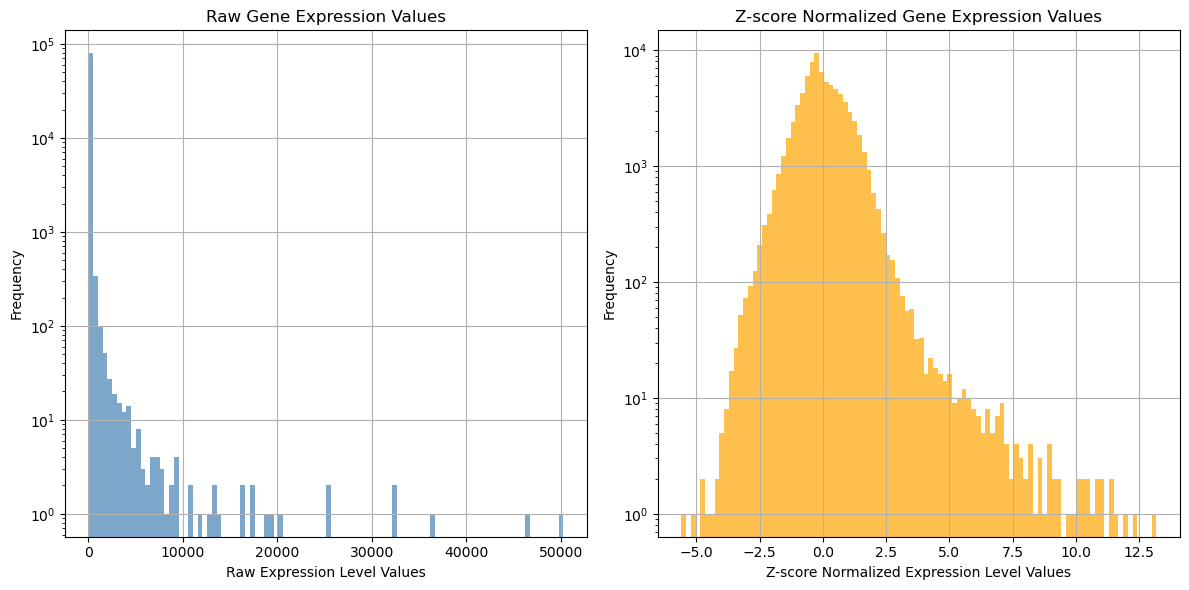

In [43]:
def present_data(data, label, norm_data):
    print("Data shape:", data.shape)
    print("Label shape:", label.shape)
    print(f"AML", np.sum(label == 0), "ALL", np.sum(label == 1), "Normal", np.sum(label == 2))

    # Flatten the matrix (5000 subjects × 60,000 genes) into a 1D array
    raw_flat_gene_expr = data.flatten()
    norm_flat_gene_expr = norm_data.flatten()

    # Plot distributions in two subplots
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(raw_flat_gene_expr, bins=100, color='steelblue', alpha=0.7)
    plt.title("Raw Gene Expression Values")
    plt.xlabel("Raw Expression Level Values")
    plt.ylabel("Frequency")
    plt.grid()
    plt.yscale('log')  # Optional: log scale helps if values span wide range
    plt.subplot(1, 2, 2)
    plt.hist(norm_flat_gene_expr, bins=100, color='orange', alpha=0.7)
    plt.title("Z-score Normalized Gene Expression Values")
    plt.xlabel("Z-score Normalized Expression Level Values")
    plt.ylabel("Frequency")
    plt.grid()
    plt.yscale('log')  # Optional: log scale helps if values span wide range
    plt.tight_layout()
    plt.show()



present_data(X_train, y_train, X_norm)


# Supervised PPCA model

In [33]:
def supervised_ppca_model(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape

    W = pyro.sample("W", dist.Normal(0., 1.).expand([latent_dim, n_genes]).to_event(2))

    # Sigma is now a per-gene parameter
    sigma = pyro.param("sigma_loc", torch.full((n_genes,), 0.3), constraint=dist.constraints.positive)

    # Classifier weights and biases
    A = pyro.sample("A", dist.Normal(0., 1.).expand([n_classes, latent_dim]).to_event(2))
    b = pyro.sample("b", dist.Normal(0., 1.).expand([n_classes]).to_event(1))


    class_weights = compute_class_weight('balanced', classes=np.unique(y.numpy()), y=y.numpy())
    class_weights = torch.tensor(class_weights, dtype=torch.float32)

    with pyro.plate("data", n_samples):
        # Sample latent variable
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))

        # Likelihood for gene expression
        x_loc = torch.matmul(z, W)
        pyro.sample("obs", dist.Normal(x_loc, sigma).to_event(1), obs=X)

        logits = torch.matmul(z, A.T) + b
        weighted_logits = logits + torch.log(class_weights)  # Add log class weights
        pyro.sample("y", dist.Categorical(logits=weighted_logits), obs=y)




def supervised_ppca_guide(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape

    # Posterior over W
    w_loc = pyro.param("w_loc", torch.randn(latent_dim, n_genes))
    w_scale = pyro.param("w_scale", torch.ones(latent_dim, n_genes), constraint=dist.constraints.positive)
    pyro.sample("W", dist.Normal(w_loc, w_scale).to_event(2))


    a_loc = pyro.param("a_loc", torch.randn(n_classes, latent_dim))
    a_scale = pyro.param("a_scale", torch.ones(n_classes, latent_dim), constraint=dist.constraints.positive)
    pyro.sample("A", dist.Normal(a_loc, a_scale).to_event(2))

    b_loc = pyro.param("b_loc", torch.zeros(n_classes))
    b_scale = pyro.param("b_scale", torch.ones(n_classes), constraint=dist.constraints.positive)
    pyro.sample("b", dist.Normal(b_loc, b_scale).to_event(1))


    # Posterior over z
    z_loc = pyro.param("z_loc", torch.randn(n_samples, latent_dim))
    z_scale = pyro.param("z_scale", torch.ones(n_samples, latent_dim), constraint=dist.constraints.positive)
    with pyro.plate("data", n_samples):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))

        

### Train model

In [34]:
def SVI_PPCA(X_train, y_train, latent_dim, n_classes, n_steps=3000):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    pyro.clear_param_store()
    optimizer = Adam({"lr": 0.05})
    svi = SVI(supervised_ppca_model, supervised_ppca_guide, optimizer, loss=Trace_ELBO())

    start_time = time.time()

    for step in range(n_steps):
        loss = svi.step(X_train_tensor, y_train_tensor, latent_dim, n_classes)
        if step % (n_steps // 10) == 0:
            print(f"[Step {step}] Loss: {loss:.2f}")

    # Total time spent
    print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")

    #Print learned sigma
    print("Learned sigma:", pyro.param("sigma_loc").detach().numpy())


latent_dim = 100
n_classes = 3

SVI_PPCA(X_norm, y_train, latent_dim, n_classes, n_steps=SVI_PPCA_n_steps)

[Step 0] Loss: 180523534.52
[Step 300] Loss: 362991.09
[Step 600] Loss: 227321.64
[Step 900] Loss: 199889.82
[Step 1200] Loss: 187834.30
[Step 1500] Loss: 182917.34
[Step 1800] Loss: 180533.51
[Step 2100] Loss: 177981.35
[Step 2400] Loss: 176206.78
[Step 2700] Loss: 174669.29
Total time spent: 37.92 seconds (0.63 minutes)
Learned sigma: [1.3498638  1.1739005  1.2742281  1.1932576  1.2642391  1.210975
 1.2961831  1.1689694  1.2670482  1.2502644  1.2037911  1.1714016
 1.1626543  1.2799919  1.2857381  1.2147118  1.1712267  1.3223639
 1.1601036  1.2039716  1.24218    1.304959   1.3523672  1.2880968
 0.97185093 1.32667    1.3567071  1.4173021  1.3605498  1.235045
 1.2222958  1.2028061  1.3358645  1.133984   1.2952267  1.3637881
 1.309779   1.3966458  1.2348053  1.2224414  1.1919221  1.2920207
 1.2173077  1.1832623  1.217476   1.384102   1.2047895  1.2568554
 1.1354523  1.2412899  1.238035   1.3114177  1.327008   1.1632321
 1.1933593  1.349935   1.2527273  1.2637562  1.3626709  1.3476163
 1.

In [35]:
print(list(pyro.get_param_store().keys()))

['w_loc', 'w_scale', 'a_loc', 'a_scale', 'b_loc', 'b_scale', 'z_loc', 'z_scale', 'sigma_loc']


# Exploring Latent space

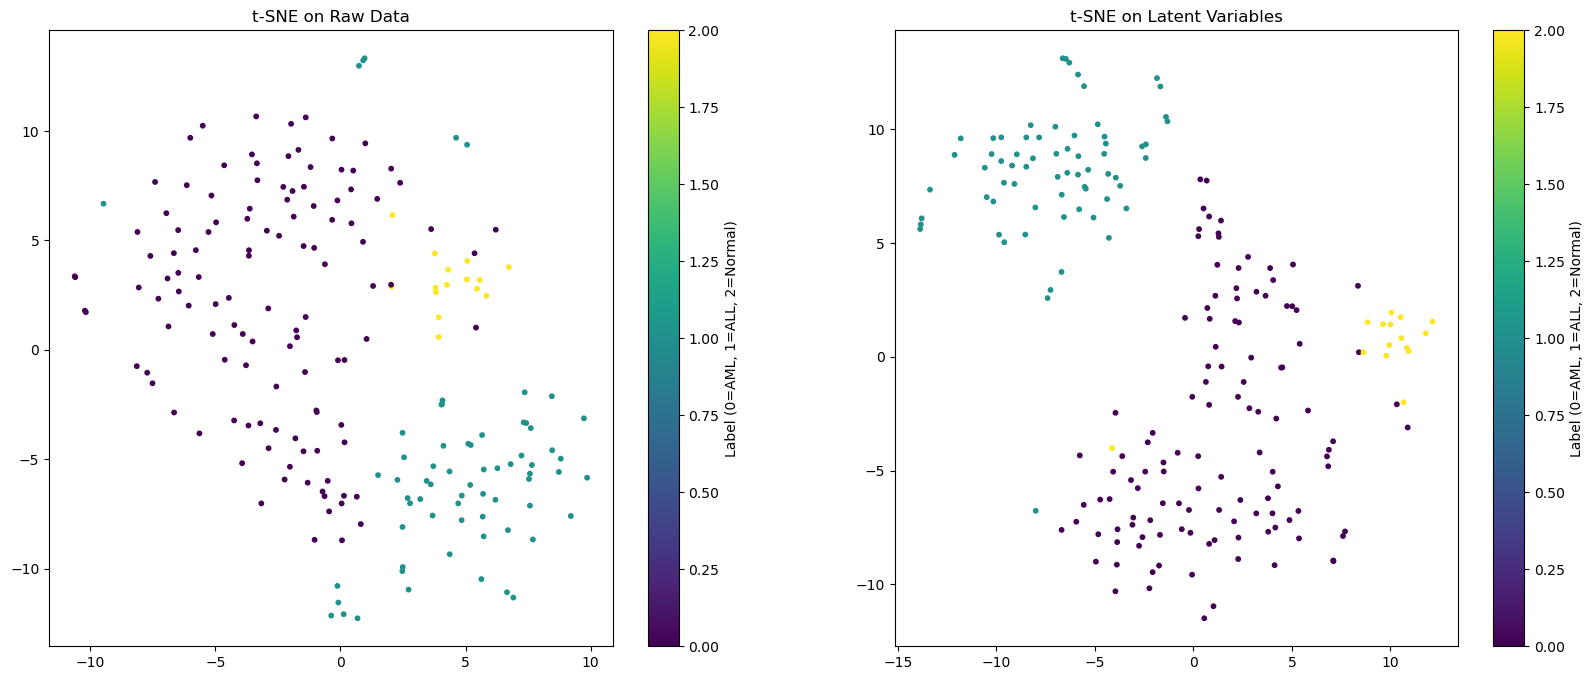

In [36]:
def TSNE_plots(z_loc, labels):
    raw_data_tsne = TSNE(n_components=2).fit_transform(X_norm)
    z_post_tsne = TSNE(n_components=2).fit_transform(z_loc.detach().cpu().numpy())

    # subplot 1: t-SNE on raw data
    plt.figure(figsize=(20, 8))
    plt.subplot(1, 2, 1)
    plt.scatter(raw_data_tsne[:, 0], raw_data_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Raw Data")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.subplot(1, 2, 2)
    plt.scatter(z_post_tsne[:, 0], z_post_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Latent Variables")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.show()


z_loc = pyro.param("z_loc").detach()

TSNE_plots(z_loc, y_train)

# Prediction on Validation data

### Freeze model parameters for prediction

In [37]:
ps       = pyro.get_param_store()
W_pm     = ps["w_loc"].detach()                    # [latent_dim, n_genes]
sigma_pm = ps["sigma_loc"].detach()                # scalar or [n_genes]
A_pm     = ps["a_loc"].detach()                    # [n_classes, latent_dim]
b_pm     = ps["b_loc"].detach()                    # [n_classes]

### Model for inference on z (latent space)

In [38]:
def infer_z_val_model(X_val_tensor, latent_dim):
    n_val = X_val_tensor.shape[0]

    with pyro.plate("data", n_val):
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
        x_loc = torch.matmul(z, W_pm)
        pyro.sample("obs", dist.Normal(x_loc, sigma_pm).to_event(1), obs=X_val_tensor)
        

def infer_z_val_guide(X_val_tensor, latent_dim):
    n_val = X_val_tensor.shape[0]

    # New variational parameters for validation latent space
    z_loc_val = pyro.param("z_loc_val", torch.randn(n_val, latent_dim))
    z_scale_val = pyro.param("z_scale_val", torch.ones(n_val, latent_dim), constraint=dist.constraints.positive)

    with pyro.plate("data", n_val):
        pyro.sample("z", dist.Normal(z_loc_val, z_scale_val).to_event(1))


In [ ]:
def SVI_z(X_val_tensor, latent_dim, n_steps):
    optimizer = ClippedAdam({"lr": 0.02})
    svi = SVI(infer_z_val_model, infer_z_val_guide, optimizer, loss=Trace_ELBO())

    start_time = time.time()

    for step in range(n_steps):
        loss = svi.step(X_val_tensor, latent_dim)

        if step % (n_steps // 10) == 0:
            print(f"[Step {step}] Loss: {loss:.2f}")

    # Total time spent
    print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")





X_val_norm = normalize_data(np.log2(X_val+1))[0]
X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32)



SVI_z(X_val_tensor, latent_dim, n_steps=SVI_z_n_steps)

print("Learned sigma:", pyro.param("sigma_loc").detach().numpy())

Sum of X_train_mean: 15724.004
Sum of X_train_std: 18666.312
Sum of X_clipped: -143.1835
Sum of X_norm: -0.00017261505
[Step 0] Loss: 231404.09
[Step 300] Loss: 124122.74
[Step 600] Loss: 121345.12
[Step 900] Loss: 120734.78
[Step 1200] Loss: 120543.79
[Step 1500] Loss: 120387.58
[Step 1800] Loss: 120626.92
[Step 2100] Loss: 120677.96
[Step 2400] Loss: 120439.81
[Step 2700] Loss: 121013.63
Total time spent: 13.62 seconds (0.23 minutes)
Learned sigma: [1.3498638  1.1739005  1.2742281  1.1932576  1.2642391  1.210975
 1.2961831  1.1689694  1.2670482  1.2502644  1.2037911  1.1714016
 1.1626543  1.2799919  1.2857381  1.2147118  1.1712267  1.3223639
 1.1601036  1.2039716  1.24218    1.304959   1.3523672  1.2880968
 0.97185093 1.32667    1.3567071  1.4173021  1.3605498  1.235045
 1.2222958  1.2028061  1.3358645  1.133984   1.2952267  1.3637881
 1.309779   1.3966458  1.2348053  1.2224414  1.1919221  1.2920207
 1.2173077  1.1832623  1.217476   1.384102   1.2047895  1.2568554
 1.1354523  1.24128

Validation Accuracy: 0.9300


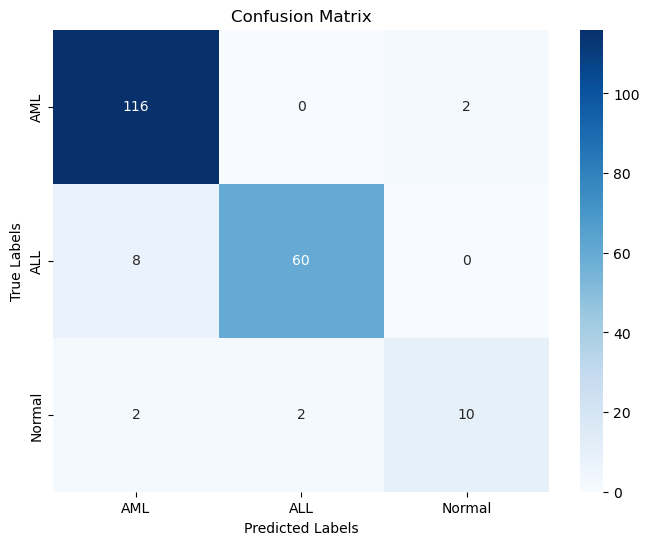

In [40]:
def predict_classes(z_loc, A, b, y_true):
    # Predict class labels using the learned latent representation
    logits = torch.matmul(z_loc, A.T) + b
    probs = torch.softmax(logits, dim=-1)
    y_hat = torch.argmax(probs, dim=-1).numpy()
    
    # Compute accuracy
    y_true = torch.tensor(y_true, dtype=torch.long).numpy()
    accuracy = (y_true == y_hat).mean()
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Compute and plot confusion matrix
    conf_matrix = confusion_matrix(y_true, y_hat)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["AML", "ALL", "Normal"], yticklabels=["AML", "ALL", "Normal"])
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()
    return y_hat


z_loc_val = pyro.param("z_loc_val").detach()  # shape: [n_val_samples, latent_dim]

y_hat_val = predict_classes(z_loc_val, A_pm, b_pm, y_val)


# Evaluating importance of features (genes)

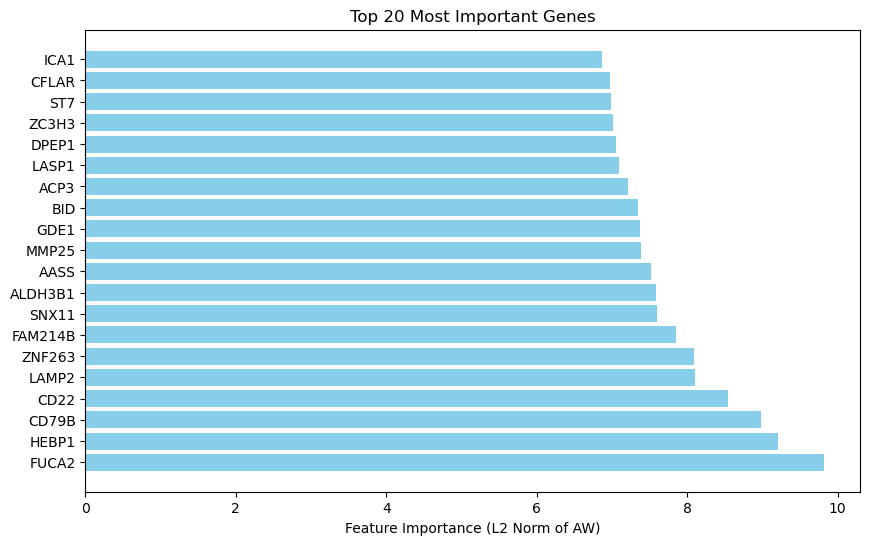

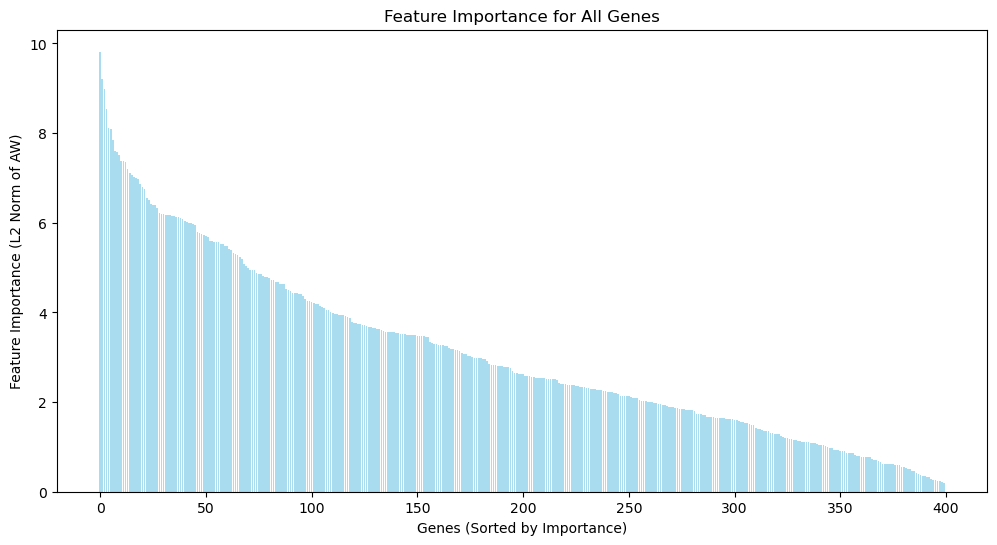

In [41]:
# Example usage
W = pyro.param("w_loc").detach().cpu().numpy()  # Shape: [latent_dim, n_genes]
A = A_pm.detach().cpu().numpy()                # Shape: [n_classes, latent_dim]
top_n = 20
gene_importance = np.linalg.norm(A @ W, axis=0)  # Compute importance for all genes


# Compute feature importance
top_indices, top_importance = compute_feature_importance_from_AW(W, A, top_n=top_n)

# Plot the top genes
plot_top_genes_from_AW(top_indices, top_importance, top_n=top_n, gene_names=gene_names)
plot_all_genes_from_AW(gene_importance)